### Email Campaign Analysis at an E-commerce Company

You're a junior analyst at an e-commerce company, and your marketing manager asks you to analyze customer engagement with email campaigns. The company sends out four types of promotional emails: New Product Announcements, Flash Sales, Seasonal Promotions, and Loyalty Rewards.

Based on historical data, these emails typically get engagement in the following proportions:
- New Product Announcements: 35%
- Flash Sales: 30%
- Seasonal Promotions: 20%
- Loyalty Rewards: 15%

#### Implementation of Analysis in Code

After implementing a new email design template, your manager wants to know if customer engagement patterns have changed. 

Email Engagement Analysis Report

Detailed Comparison:
 Email Type  Observed Count  Expected Count  Observed %  Expected %  Difference
New Product             420           420.0        35.0        35.0         0.0
Flash Sales             380           360.0        31.7        30.0         1.7
   Seasonal             160           240.0        13.3        20.0        -6.7
    Loyalty             240           180.0        20.0        15.0         5.0

Statistical Test Results:
Chi-squared statistic: 47.78
P-value: 0.0000

Interpretation:
There is significant evidence that the new email template
has changed engagement patterns (p < 0.05)

Biggest changes in engagement:
Seasonal: -6.7% difference
Loyalty: +5.0% difference
Flash Sales: +1.7% difference
New Product: +0.0% difference


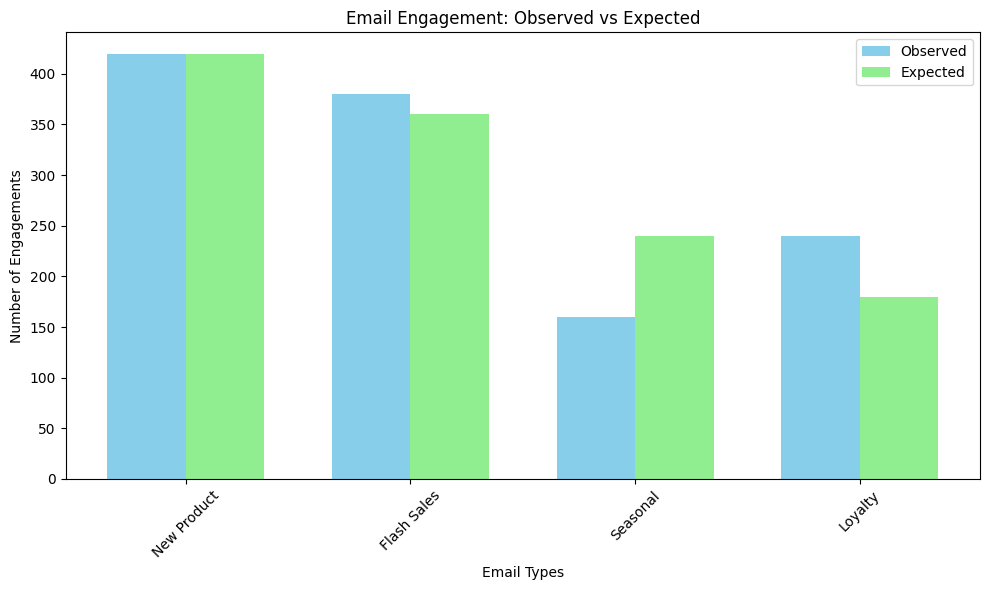

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

def analyze_email_engagement(observed_counts, expected_proportions, email_types):
    """
    Analyzes whether email engagement patterns match historical patterns
    
    Parameters:
        observed_counts: Array of engagement counts for each email type
        expected_proportions: Array of historical engagement proportions
        email_types: List of email category names
    """
    # Calculate total observations and expected counts
    total_engagements = sum(observed_counts)
    expected_counts = total_engagements * expected_proportions
    
    # Perform chi-squared test
    test_statistic, p_value = stats.chisquare(observed_counts, expected_counts)
    
    # Create comparison DataFrame for clear reporting
    comparison_df = pd.DataFrame({
        'Email Type': email_types,
        'Observed Count': observed_counts,
        'Expected Count': expected_counts,
        'Observed %': (observed_counts / total_engagements * 100).round(1),
        'Expected %': (expected_proportions * 100).round(1),
        'Difference': ((observed_counts / total_engagements - expected_proportions) * 100).round(1)
    })
    
    # Visualize the comparison
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    index = np.arange(len(email_types))
    
    plt.bar(index, observed_counts, bar_width, label='Observed',
            color='skyblue')
    plt.bar(index + bar_width, expected_counts, bar_width,
            label='Expected', color='lightgreen')
    
    plt.xlabel('Email Types')
    plt.ylabel('Number of Engagements')
    plt.title('Email Engagement: Observed vs Expected')
    plt.xticks(index + bar_width/2, email_types, rotation=45)
    plt.legend()
    plt.tight_layout()
    
    # Print detailed analysis
    print("Email Engagement Analysis Report")
    print("=" * 50)
    print("\nDetailed Comparison:")
    print(comparison_df.to_string(index=False))
    print("\nStatistical Test Results:")
    print(f"Chi-squared statistic: {test_statistic:.2f}")
    print(f"P-value: {p_value:.4f}")
    print("\nInterpretation:")
    if p_value < 0.05:
        print("There is significant evidence that the new email template")
        print("has changed engagement patterns (p < 0.05)")
        
        # Find biggest changes
        differences = comparison_df.sort_values('Difference', key=abs, ascending=False)
        print("\nBiggest changes in engagement:")
        for _, row in differences.iterrows():
            print(f"{row['Email Type']}: {row['Difference']:+.1f}% difference")
    else:
        print("There is no significant evidence that the new email template")
        print("has changed engagement patterns (p >= 0.05)")

# Your recent data after implementing the new template
email_types = ['New Product', 'Flash Sales', 'Seasonal', 'Loyalty']
observed_counts = np.array([420, 380, 160, 240])  # 1200 total engagements
expected_proportions = np.array([0.35, 0.30, 0.20, 0.15])

# Run the analysis
analyze_email_engagement(observed_counts, expected_proportions, email_types)